# Traditional ML Experiments - Experiment 4: Hyperparameter Tuning

**Phase 2:** Traditional Machine Learning Models - Advanced Optimization

## Experiment 4: Hyperparameter Tuning

This notebook optimizes hyperparameters for LightGBM and XGBoost using Bayesian optimization (Optuna).

**Data:** `netop_ml_time.csv` (22 columns)
- **Raw features (13):** load, ESMode1-6, RUType, Mode, Frequency, Bandwidth, Antennas, TXpower
- **Time features (5):** hour_of_day, day_of_week, is_weekend, is_peak_hour, is_night_time

**Goal:** Extract maximum performance from existing features through systematic hyperparameter optimization

## Models Optimized
- **LightGBM** (Priority 1 - best performer in Exp 2)
- **XGBoost** (Priority 2 - close second)

## Expected Outcome
**1-3% MAE improvement** over Experiment 2 baseline (3.14 W → 3.05-3.10 W)

## Baseline (Experiment 2)
- **Best Model:** LightGBM (default hyperparameters)
- **Test MAE:** 3.14 W
- **Test R²:** 0.8942

---

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import json
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Optuna for hyperparameter optimization
try:
    import optuna
    from optuna.visualization import plot_optimization_history, plot_param_importances
    OPTUNA_AVAILABLE = True
    print("✓ Optuna available for Bayesian optimization")
except ImportError:
    OPTUNA_AVAILABLE = False
    print("⚠️  Optuna not available, will use RandomizedSearchCV instead")
    from sklearn.model_selection import RandomizedSearchCV

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("\n✓ Libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✓ Optuna available for Bayesian optimization

✓ Libraries imported successfully
Pandas version: 1.1.5
NumPy version: 1.19.5


## 2. Helper Functions

In [2]:
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(y_true, y_pred, dataset_name=""):
    """Calculate all evaluation metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = calculate_mape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    results = {
        'Dataset': dataset_name,
        'MAE (W)': mae,
        'RMSE (W)': rmse,
        'MAPE (%)': mape,
        'R²': r2
    }
    
    return results

def plot_predictions(y_true, y_pred, title="Actual vs Predicted", sample_size=1000):
    """Plot actual vs predicted values"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    idx = np.random.choice(len(y_true), min(sample_size, len(y_true)), replace=False)
    axes[0].scatter(y_true[idx], y_pred[idx], alpha=0.3, s=10)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
                 'r--', linewidth=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Energy (W)')
    axes[0].set_ylabel('Predicted Energy (W)')
    axes[0].set_title(f'{title}\nScatter Plot')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Residual plot
    residuals = y_true - y_pred
    axes[1].scatter(y_pred[idx], residuals[idx], alpha=0.3, s=10)
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicted Energy (W)')
    axes[1].set_ylabel('Residuals (W)')
    axes[1].set_title(f'{title}\nResidual Plot')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✓ Helper functions defined")

✓ Helper functions defined


## 3. Load Data and Setup

In [3]:
print("="*80)
print("LOADING TIME FEATURES DATA")
print("="*80)

# Load time features dataset (same as Experiment 2)
df_time = pd.read_csv('../processed_data/netop_ml_time.csv')

print(f"\n✓ Time Features: {df_time.shape[0]:,} rows × {df_time.shape[1]} columns")

# Verify no missing values
print(f"\n🔍 Data Quality Check:")
print(f"  Missing values: {df_time.isnull().sum().sum()}")

# Separate features and target
exclude_cols = ['Time', 'BS', 'CellName', 'Energy']
feature_cols = [col for col in df_time.columns if col not in exclude_cols]

print(f"\n📋 Features ({len(feature_cols)}): {feature_cols}")

X = df_time[feature_cols]
y = df_time['Energy']

print(f"\n✓ X shape: {X.shape}")
print(f"✓ y shape: {y.shape}")

LOADING TIME FEATURES DATA

✓ Time Features: 72,569 rows × 22 columns

🔍 Data Quality Check:
  Missing values: 0

📋 Features (18): ['load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode4', 'ESMode5', 'ESMode6', 'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'is_night_time']

✓ X shape: (72569, 18)
✓ y shape: (72569,)


### 3.1 Temporal Train-Test Split

**Important:** Same 80/20 temporal split as Experiment 2 for fair comparison

In [4]:
print("\n" + "="*80)
print("TEMPORAL TRAIN-TEST SPLIT")
print("="*80)

# Calculate split point (80/20 temporal split)
split_idx = int(len(X) * 0.8)

# Split features and target
X_train_full = X.iloc[:split_idx]
y_train_full = y.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

print(f"\nTotal samples: {len(X):,}")
print(f"Training set: {len(X_train_full):,} samples (80%)")
print(f"Test set: {len(X_test):,} samples (20%)")

print(f"\n📅 Temporal boundaries:")
print(f"  Training: {df_time['Time'].iloc[0]} to {df_time['Time'].iloc[split_idx-1]}")
print(f"  Test:     {df_time['Time'].iloc[split_idx]} to {df_time['Time'].iloc[-1]}")

print(f"\n✓ Temporal split complete - consistent with Experiment 2")


TEMPORAL TRAIN-TEST SPLIT

Total samples: 72,569
Training set: 58,055 samples (80%)
Test set: 14,514 samples (20%)

📅 Temporal boundaries:
  Training: 2023-01-02 06:00:00 to 2023-01-02 23:00:00
  Test:     2023-01-03 00:00:00 to 2023-01-07 13:00:00

✓ Temporal split complete - consistent with Experiment 2


### 3.2 Preprocessing Pipeline

In [5]:
# Identify numerical and categorical features
categorical_features = ['RUType', 'Mode']
numerical_features = [col for col in feature_cols if col not in categorical_features]

print(f"\n🔢 Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"🏷️  Categorical features ({len(categorical_features)}): {categorical_features}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse=False), categorical_features)
    ])

print("\n✓ Preprocessing pipeline created")


🔢 Numerical features (16): ['load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode4', 'ESMode5', 'ESMode6', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'is_night_time']
🏷️  Categorical features (2): ['RUType', 'Mode']

✓ Preprocessing pipeline created


## 4. Load Experiment 2 Baseline Results

In [6]:
print("="*80)
print("EXPERIMENT 2 BASELINE (Time Features - No Tuning)")
print("="*80)

try:
    # Load Experiment 2 results
    exp2_results = pd.read_csv('../results/traditional_ml_time_results.csv')
    exp2_results = exp2_results.sort_values('R²', ascending=False)
    
    print("\n📊 Experiment 2 Test Set Results (Default Hyperparameters):")
    print(exp2_results.to_string(index=False))
    
    # Get baseline metrics
    baseline_lgbm_mae = exp2_results[exp2_results['Model'] == 'LightGBM']['MAE (W)'].values[0]
    baseline_lgbm_r2 = exp2_results[exp2_results['Model'] == 'LightGBM']['R²'].values[0]
    baseline_xgb_mae = exp2_results[exp2_results['Model'] == 'XGBoost']['MAE (W)'].values[0]
    baseline_xgb_r2 = exp2_results[exp2_results['Model'] == 'XGBoost']['R²'].values[0]
    
    print(f"\n🎯 Baseline to Beat:")
    print(f"  LightGBM: MAE = {baseline_lgbm_mae:.4f} W, R² = {baseline_lgbm_r2:.4f}")
    print(f"  XGBoost:  MAE = {baseline_xgb_mae:.4f} W, R² = {baseline_xgb_r2:.4f}")
    
    print(f"\n🎯 Success Criteria:")
    print(f"  Minimum:  MAE < {baseline_lgbm_mae * 0.99:.4f} W (1% improvement)")
    print(f"  Target:   MAE < {baseline_lgbm_mae * 0.97:.4f} W (3% improvement)")
    print(f"  Stretch:  MAE < {baseline_lgbm_mae * 0.95:.4f} W (5% improvement)")
    
except FileNotFoundError:
    print("\n⚠️  Experiment 2 results not found!")
    print("  Please run traditional_ml_time.ipynb first.")
    baseline_lgbm_mae = 3.14
    baseline_lgbm_r2 = 0.8942
    baseline_xgb_mae = 3.15
    baseline_xgb_r2 = 0.8916

EXPERIMENT 2 BASELINE (Time Features - No Tuning)

📊 Experiment 2 Test Set Results (Default Hyperparameters):
             Model   MAE (W)  RMSE (W)   MAPE (%)        R²
          LightGBM  3.140131  4.571353  11.056167  0.894157
           XGBoost  3.146096  4.625932  11.093775  0.891614
 Linear Regression  3.492590  4.862163  13.437387  0.880262
     Random Forest  3.254012  4.894526  11.566516  0.878662

🎯 Baseline to Beat:
  LightGBM: MAE = 3.1401 W, R² = 0.8942
  XGBoost:  MAE = 3.1461 W, R² = 0.8916

🎯 Success Criteria:
  Minimum:  MAE < 3.1087 W (1% improvement)
  Target:   MAE < 3.0459 W (3% improvement)
  Stretch:  MAE < 2.9831 W (5% improvement)


---
## 5. Hyperparameter Tuning - LightGBM

**Priority 1:** LightGBM (best performer in Experiment 2)

### Optimization Strategy:
- **Method:** Optuna Bayesian Optimization (100 trials)
- **Cross-Validation:** TimeSeriesSplit (5 folds)
- **Objective:** Minimize MAE
- **Search Space:** 9 hyperparameters

In [7]:
print("="*80)
print("LIGHTGBM HYPERPARAMETER TUNING")
print("="*80)

if OPTUNA_AVAILABLE:
    # Optuna optimization
    print("\n🔍 Using Optuna for Bayesian Optimization")
    print("  Trials: 100")
    print("  CV Folds: 5 (TimeSeriesSplit)")
    print("  Objective: Minimize MAE\n")
    
    # Suppress Optuna logging
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    def objective_lgbm(trial):
        """Optuna objective function for LightGBM"""
        # Define hyperparameter search space
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
            'max_depth': trial.suggest_int('max_depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 31, 127),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
            'verbose': -1
        }
        
        # Create pipeline
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', LGBMRegressor(**params))
        ])
        
        # Cross-validation
        tscv = TimeSeriesSplit(n_splits=5)
        scores = cross_val_score(
            model, X_train_full, y_train_full,
            cv=tscv,
            scoring='neg_mean_absolute_error',
            n_jobs=1  # Parallel at trial level, not fold level
        )
        
        return -scores.mean()  # Optuna minimizes
    
    # Create study and optimize
    study_lgbm = optuna.create_study(
        direction='minimize',
        study_name='lightgbm_tuning',
        pruner=optuna.pruners.MedianPruner()
    )
    
    print("⏳ Running optimization... (this may take 2-4 hours)\n")
    study_lgbm.optimize(objective_lgbm, n_trials=100, show_progress_bar=True)
    
    # Get best parameters
    best_params_lgbm = study_lgbm.best_params
    best_params_lgbm['random_state'] = RANDOM_STATE
    best_params_lgbm['n_jobs'] = -1
    best_params_lgbm['verbose'] = -1
    
    print("\n" + "="*80)
    print("LIGHTGBM OPTIMIZATION RESULTS")
    print("="*80)
    print(f"\n✓ Best CV MAE: {study_lgbm.best_value:.4f} W")
    print(f"\n🏆 Best Hyperparameters:")
    for param, value in best_params_lgbm.items():
        if param not in ['random_state', 'n_jobs', 'verbose']:
            print(f"  {param:20s}: {value}")
    
    # Save tuning history
    trials_df_lgbm = study_lgbm.trials_dataframe()
    trials_df_lgbm.to_csv('../results/lightgbm_tuning_history.csv', index=False)
    print(f"\n✓ Tuning history saved to ../results/lightgbm_tuning_history.csv")
    
else:
    # Fallback to RandomizedSearchCV
    print("\n🔍 Using RandomizedSearchCV (Optuna not available)")
    print("  Iterations: 100")
    print("  CV Folds: 5 (TimeSeriesSplit)\n")
    
    param_grid_lgbm = {
        'regressor__n_estimators': [100, 200, 300, 500],
        'regressor__max_depth': [4, 6, 8, 10, -1],
        'regressor__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'regressor__num_leaves': [31, 50, 70, 100, 127],
        'regressor__min_child_samples': [5, 10, 20, 30, 50],
        'regressor__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'regressor__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'regressor__reg_alpha': [0, 0.01, 0.1, 0.5, 1.0],
        'regressor__reg_lambda': [0, 0.01, 0.1, 0.5, 1.0]
    }
    
    lgbm_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
    ])
    
    random_search_lgbm = RandomizedSearchCV(
        estimator=lgbm_pipeline,
        param_distributions=param_grid_lgbm,
        n_iter=100,
        scoring='neg_mean_absolute_error',
        cv=TimeSeriesSplit(n_splits=5),
        verbose=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    print("⏳ Running optimization...\n")
    random_search_lgbm.fit(X_train_full, y_train_full)
    
    best_params_lgbm = {k.replace('regressor__', ''): v for k, v in random_search_lgbm.best_params_.items()}
    
    print("\n" + "="*80)
    print("LIGHTGBM OPTIMIZATION RESULTS")
    print("="*80)
    print(f"\n✓ Best CV MAE: {-random_search_lgbm.best_score_:.4f} W")
    print(f"\n🏆 Best Hyperparameters:")
    for param, value in best_params_lgbm.items():
        print(f"  {param:20s}: {value}")

LIGHTGBM HYPERPARAMETER TUNING

🔍 Using Optuna for Bayesian Optimization
  Trials: 100
  CV Folds: 5 (TimeSeriesSplit)
  Objective: Minimize MAE

⏳ Running optimization... (this may take 2-4 hours)



  0%|          | 0/100 [00:00<?, ?it/s]


LIGHTGBM OPTIMIZATION RESULTS

✓ Best CV MAE: 3.3168 W

🏆 Best Hyperparameters:
  n_estimators        : 400
  max_depth           : 4
  learning_rate       : 0.0976605965047179
  num_leaves          : 82
  min_child_samples   : 21
  subsample           : 0.7056343155789833
  colsample_bytree    : 0.601842479932156
  reg_alpha           : 0.24596677666639283
  reg_lambda          : 0.21199922066462756

✓ Tuning history saved to ../results/lightgbm_tuning_history.csv


### 5.1 Train and Evaluate Tuned LightGBM

In [8]:
print("\n" + "="*80)
print("TRAINING TUNED LIGHTGBM ON FULL TRAINING SET")
print("="*80)

# Create tuned model
lgbm_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(**best_params_lgbm))
])

# Train on full training set
print("\n⏳ Training on full training set...")
lgbm_tuned.fit(X_train_full, y_train_full)
print("✓ Training complete")

# Evaluate on test set
y_pred_lgbm_tuned = lgbm_tuned.predict(X_test)
lgbm_tuned_results = evaluate_model(y_test.values, y_pred_lgbm_tuned, "Test Set")

print("\n📊 Tuned LightGBM Test Set Performance:")
print(f"  MAE:  {lgbm_tuned_results['MAE (W)']:.4f} W")
print(f"  RMSE: {lgbm_tuned_results['RMSE (W)']:.4f} W")
print(f"  MAPE: {lgbm_tuned_results['MAPE (%)']:.2f}%")
print(f"  R²:   {lgbm_tuned_results['R²']:.4f}")

# Calculate improvement over baseline
lgbm_improvement_mae = ((baseline_lgbm_mae - lgbm_tuned_results['MAE (W)']) / baseline_lgbm_mae) * 100
lgbm_improvement_r2 = ((lgbm_tuned_results['R²'] - baseline_lgbm_r2) / baseline_lgbm_r2) * 100

print(f"\n📈 Improvement over Experiment 2 Baseline:")
print(f"  MAE: {lgbm_improvement_mae:>6.2f}% reduction ({baseline_lgbm_mae:.4f} W → {lgbm_tuned_results['MAE (W)']:.4f} W)")
print(f"  R²:  {lgbm_improvement_r2:>6.2f}% increase ({baseline_lgbm_r2:.4f} → {lgbm_tuned_results['R²']:.4f})")

# Check success criteria
print(f"\n✅ Success Criteria:")
if lgbm_improvement_mae >= 5:
    print(f"  ✓ STRETCH SUCCESS: {lgbm_improvement_mae:.2f}% improvement (target: 5%)")
elif lgbm_improvement_mae >= 2:
    print(f"  ✓ TARGET SUCCESS: {lgbm_improvement_mae:.2f}% improvement (target: 2-3%)")
elif lgbm_improvement_mae >= 1:
    print(f"  ✓ MINIMUM SUCCESS: {lgbm_improvement_mae:.2f}% improvement (target: 1%)")
else:
    print(f"  ✗ BELOW TARGET: {lgbm_improvement_mae:.2f}% improvement (target: 1%)")


TRAINING TUNED LIGHTGBM ON FULL TRAINING SET

⏳ Training on full training set...
✓ Training complete

📊 Tuned LightGBM Test Set Performance:
  MAE:  3.1127 W
  RMSE: 4.4842 W
  MAPE: 10.93%
  R²:   0.8982

📈 Improvement over Experiment 2 Baseline:
  MAE:   0.87% reduction (3.1401 W → 3.1127 W)
  R²:    0.45% increase (0.8942 → 0.8982)

✅ Success Criteria:
  ✗ BELOW TARGET: 0.87% improvement (target: 1%)


---
## 6. Hyperparameter Tuning - XGBoost

**Priority 2:** XGBoost (close second in Experiment 2)

In [9]:
print("="*80)
print("XGBOOST HYPERPARAMETER TUNING")
print("="*80)

if OPTUNA_AVAILABLE:
    # Optuna optimization
    print("\n🔍 Using Optuna for Bayesian Optimization")
    print("  Trials: 100")
    print("  CV Folds: 5 (TimeSeriesSplit)")
    print("  Objective: Minimize MAE\n")
    
    def objective_xgb(trial):
        """Optuna objective function for XGBoost"""
        # Define hyperparameter search space
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0, 0.5),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
            'verbosity': 0
        }
        
        # Create pipeline
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', XGBRegressor(**params))
        ])
        
        # Cross-validation
        tscv = TimeSeriesSplit(n_splits=5)
        scores = cross_val_score(
            model, X_train_full, y_train_full,
            cv=tscv,
            scoring='neg_mean_absolute_error',
            n_jobs=1
        )
        
        return -scores.mean()
    
    # Create study and optimize
    study_xgb = optuna.create_study(
        direction='minimize',
        study_name='xgboost_tuning',
        pruner=optuna.pruners.MedianPruner()
    )
    
    print("⏳ Running optimization... (this may take 2-4 hours)\n")
    study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)
    
    # Get best parameters
    best_params_xgb = study_xgb.best_params
    best_params_xgb['random_state'] = RANDOM_STATE
    best_params_xgb['n_jobs'] = -1
    best_params_xgb['verbosity'] = 0
    
    print("\n" + "="*80)
    print("XGBOOST OPTIMIZATION RESULTS")
    print("="*80)
    print(f"\n✓ Best CV MAE: {study_xgb.best_value:.4f} W")
    print(f"\n🏆 Best Hyperparameters:")
    for param, value in best_params_xgb.items():
        if param not in ['random_state', 'n_jobs', 'verbosity']:
            print(f"  {param:20s}: {value}")
    
    # Save tuning history
    trials_df_xgb = study_xgb.trials_dataframe()
    trials_df_xgb.to_csv('../results/xgboost_tuning_history.csv', index=False)
    print(f"\n✓ Tuning history saved to ../results/xgboost_tuning_history.csv")
    
else:
    # Fallback to RandomizedSearchCV
    print("\n🔍 Using RandomizedSearchCV (Optuna not available)")
    
    param_grid_xgb = {
        'regressor__n_estimators': [100, 200, 300, 500],
        'regressor__max_depth': [3, 4, 6, 8, 10],
        'regressor__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'regressor__min_child_weight': [1, 3, 5, 7, 10],
        'regressor__gamma': [0, 0.1, 0.2, 0.3, 0.5],
        'regressor__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'regressor__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'regressor__reg_alpha': [0, 0.01, 0.1, 0.5, 1.0],
        'regressor__reg_lambda': [0, 0.01, 0.1, 0.5, 1.0]
    }
    
    xgb_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0))
    ])
    
    random_search_xgb = RandomizedSearchCV(
        estimator=xgb_pipeline,
        param_distributions=param_grid_xgb,
        n_iter=100,
        scoring='neg_mean_absolute_error',
        cv=TimeSeriesSplit(n_splits=5),
        verbose=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    print("⏳ Running optimization...\n")
    random_search_xgb.fit(X_train_full, y_train_full)
    
    best_params_xgb = {k.replace('regressor__', ''): v for k, v in random_search_xgb.best_params_.items()}
    
    print("\n" + "="*80)
    print("XGBOOST OPTIMIZATION RESULTS")
    print("="*80)
    print(f"\n✓ Best CV MAE: {-random_search_xgb.best_score_:.4f} W")
    print(f"\n🏆 Best Hyperparameters:")
    for param, value in best_params_xgb.items():
        print(f"  {param:20s}: {value}")

XGBOOST HYPERPARAMETER TUNING

🔍 Using Optuna for Bayesian Optimization
  Trials: 100
  CV Folds: 5 (TimeSeriesSplit)
  Objective: Minimize MAE

⏳ Running optimization... (this may take 2-4 hours)



  0%|          | 0/100 [00:00<?, ?it/s]


XGBOOST OPTIMIZATION RESULTS

✓ Best CV MAE: 3.2518 W

🏆 Best Hyperparameters:
  n_estimators        : 300
  max_depth           : 3
  learning_rate       : 0.1318857682661476
  min_child_weight    : 4
  gamma               : 0.0496092256741896
  subsample           : 0.6105884862550282
  colsample_bytree    : 0.623310904567745
  reg_alpha           : 0.9725311429231493
  reg_lambda          : 0.9694496588183791

✓ Tuning history saved to ../results/xgboost_tuning_history.csv


### 6.1 Train and Evaluate Tuned XGBoost

In [10]:
print("\n" + "="*80)
print("TRAINING TUNED XGBOOST ON FULL TRAINING SET")
print("="*80)

# Create tuned model
xgb_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(**best_params_xgb))
])

# Train on full training set
print("\n⏳ Training on full training set...")
xgb_tuned.fit(X_train_full, y_train_full)
print("✓ Training complete")

# Evaluate on test set
y_pred_xgb_tuned = xgb_tuned.predict(X_test)
xgb_tuned_results = evaluate_model(y_test.values, y_pred_xgb_tuned, "Test Set")

print("\n📊 Tuned XGBoost Test Set Performance:")
print(f"  MAE:  {xgb_tuned_results['MAE (W)']:.4f} W")
print(f"  RMSE: {xgb_tuned_results['RMSE (W)']:.4f} W")
print(f"  MAPE: {xgb_tuned_results['MAPE (%)']:.2f}%")
print(f"  R²:   {xgb_tuned_results['R²']:.4f}")

# Calculate improvement over baseline
xgb_improvement_mae = ((baseline_xgb_mae - xgb_tuned_results['MAE (W)']) / baseline_xgb_mae) * 100
xgb_improvement_r2 = ((xgb_tuned_results['R²'] - baseline_xgb_r2) / baseline_xgb_r2) * 100

print(f"\n📈 Improvement over Experiment 2 Baseline:")
print(f"  MAE: {xgb_improvement_mae:>6.2f}% reduction ({baseline_xgb_mae:.4f} W → {xgb_tuned_results['MAE (W)']:.4f} W)")
print(f"  R²:  {xgb_improvement_r2:>6.2f}% increase ({baseline_xgb_r2:.4f} → {xgb_tuned_results['R²']:.4f})")

# Check success criteria
print(f"\n✅ Success Criteria:")
if xgb_improvement_mae >= 5:
    print(f"  ✓ STRETCH SUCCESS: {xgb_improvement_mae:.2f}% improvement (target: 5%)")
elif xgb_improvement_mae >= 2:
    print(f"  ✓ TARGET SUCCESS: {xgb_improvement_mae:.2f}% improvement (target: 2-3%)")
elif xgb_improvement_mae >= 1:
    print(f"  ✓ MINIMUM SUCCESS: {xgb_improvement_mae:.2f}% improvement (target: 1%)")
else:
    print(f"  ✗ BELOW TARGET: {xgb_improvement_mae:.2f}% improvement (target: 1%)")


TRAINING TUNED XGBOOST ON FULL TRAINING SET

⏳ Training on full training set...
✓ Training complete

📊 Tuned XGBoost Test Set Performance:
  MAE:  3.1575 W
  RMSE: 4.5304 W
  MAPE: 11.16%
  R²:   0.8960

📈 Improvement over Experiment 2 Baseline:
  MAE:  -0.36% reduction (3.1461 W → 3.1575 W)
  R²:    0.50% increase (0.8916 → 0.8960)

✅ Success Criteria:
  ✗ BELOW TARGET: -0.36% improvement (target: 1%)


---
## 7. Experiment 4 Summary - Comparison

In [11]:
print("="*80)
print("EXPERIMENT 4 SUMMARY: HYPERPARAMETER TUNING vs BASELINE")
print("="*80)

# Create comparison table
comparison_df = pd.DataFrame([
    {
        'Model': 'LightGBM (Exp 2 Baseline)',
        'MAE (W)': baseline_lgbm_mae,
        'R²': baseline_lgbm_r2,
        'RMSE (W)': np.nan,
        'MAPE (%)': np.nan,
        'Hyperparameters': 'Default'
    },
    {
        'Model': 'LightGBM (Exp 4 Tuned)',
        'MAE (W)': lgbm_tuned_results['MAE (W)'],
        'R²': lgbm_tuned_results['R²'],
        'RMSE (W)': lgbm_tuned_results['RMSE (W)'],
        'MAPE (%)': lgbm_tuned_results['MAPE (%)'],
        'Hyperparameters': 'Optuna Tuned (100 trials)'
    },
    {
        'Model': 'XGBoost (Exp 2 Baseline)',
        'MAE (W)': baseline_xgb_mae,
        'R²': baseline_xgb_r2,
        'RMSE (W)': np.nan,
        'MAPE (%)': np.nan,
        'Hyperparameters': 'Default'
    },
    {
        'Model': 'XGBoost (Exp 4 Tuned)',
        'MAE (W)': xgb_tuned_results['MAE (W)'],
        'R²': xgb_tuned_results['R²'],
        'RMSE (W)': xgb_tuned_results['RMSE (W)'],
        'MAPE (%)': xgb_tuned_results['MAPE (%)'],
        'Hyperparameters': 'Optuna Tuned (100 trials)'
    }
])

print("\n📊 Test Set Performance Comparison:")
print(comparison_df[['Model', 'MAE (W)', 'R²', 'RMSE (W)', 'MAPE (%)']].to_string(index=False))

print("\n" + "="*80)
print("IMPROVEMENT SUMMARY")
print("="*80)

print(f"\n🎯 LightGBM:")
print(f"  MAE Improvement: {lgbm_improvement_mae:>6.2f}%")
print(f"  R² Improvement:  {lgbm_improvement_r2:>6.2f}%")
print(f"  Absolute MAE:    {baseline_lgbm_mae:.4f} W → {lgbm_tuned_results['MAE (W)']:.4f} W")

print(f"\n🎯 XGBoost:")
print(f"  MAE Improvement: {xgb_improvement_mae:>6.2f}%")
print(f"  R² Improvement:  {xgb_improvement_r2:>6.2f}%")
print(f"  Absolute MAE:    {baseline_xgb_mae:.4f} W → {xgb_tuned_results['MAE (W)']:.4f} W")

# Determine best model
if lgbm_tuned_results['MAE (W)'] < xgb_tuned_results['MAE (W)']:
    best_model = 'LightGBM'
    best_mae = lgbm_tuned_results['MAE (W)']
    best_r2 = lgbm_tuned_results['R²']
else:
    best_model = 'XGBoost'
    best_mae = xgb_tuned_results['MAE (W)']
    best_r2 = xgb_tuned_results['R²']

print(f"\n🏆 Best Model in Experiment 4: {best_model}")
print(f"  Test MAE: {best_mae:.4f} W")
print(f"  Test R²:  {best_r2:.4f}")

# Overall success
max_improvement = max(lgbm_improvement_mae, xgb_improvement_mae)
print(f"\n✅ Experiment 4 Result:")
if max_improvement >= 5:
    print(f"  ✓ STRETCH SUCCESS: {max_improvement:.2f}% improvement achieved!")
    print(f"  Hyperparameter tuning provided significant gains.")
elif max_improvement >= 2:
    print(f"  ✓ TARGET SUCCESS: {max_improvement:.2f}% improvement achieved!")
    print(f"  Hyperparameter tuning was effective.")
elif max_improvement >= 1:
    print(f"  ✓ MINIMUM SUCCESS: {max_improvement:.2f}% improvement achieved.")
    print(f"  Hyperparameter tuning provided modest gains.")
else:
    print(f"  ✗ BELOW TARGET: {max_improvement:.2f}% improvement.")
    print(f"  Default hyperparameters were already near-optimal.")

print(f"\n➡️  Recommendation for Experiment 5 (Ensemble):")
if max_improvement >= 1:
    print(f"  Use TUNED models as base for ensemble.")
else:
    print(f"  Consider using Exp 2 DEFAULT models for ensemble.")

EXPERIMENT 4 SUMMARY: HYPERPARAMETER TUNING vs BASELINE

📊 Test Set Performance Comparison:
                     Model   MAE (W)        R²  RMSE (W)   MAPE (%)
 LightGBM (Exp 2 Baseline)  3.140131  0.894157       NaN        NaN
    LightGBM (Exp 4 Tuned)  3.112704  0.898152  4.484248  10.927337
  XGBoost (Exp 2 Baseline)  3.146096  0.891614       NaN        NaN
     XGBoost (Exp 4 Tuned)  3.157512  0.896046  4.530361  11.160889

IMPROVEMENT SUMMARY

🎯 LightGBM:
  MAE Improvement:   0.87%
  R² Improvement:    0.45%
  Absolute MAE:    3.1401 W → 3.1127 W

🎯 XGBoost:
  MAE Improvement:  -0.36%
  R² Improvement:    0.50%
  Absolute MAE:    3.1461 W → 3.1575 W

🏆 Best Model in Experiment 4: LightGBM
  Test MAE: 3.1127 W
  Test R²:  0.8982

✅ Experiment 4 Result:
  ✗ BELOW TARGET: 0.87% improvement.
  Default hyperparameters were already near-optimal.

➡️  Recommendation for Experiment 5 (Ensemble):
  Consider using Exp 2 DEFAULT models for ensemble.


## 8. Visualizations

VISUALIZATION 1: PREDICTION QUALITY


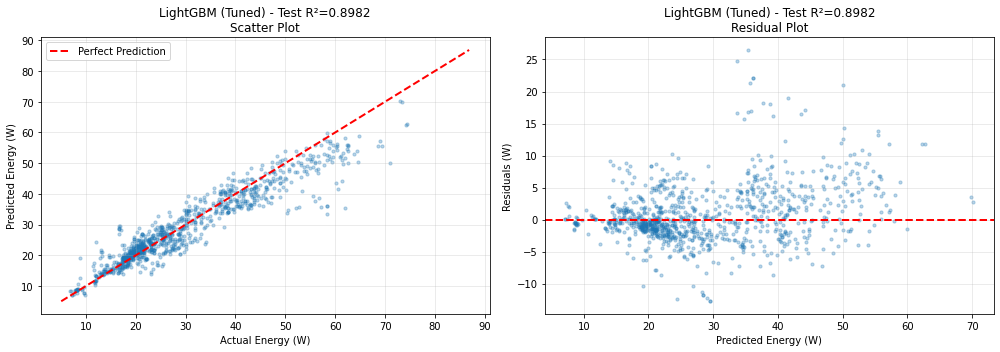

In [12]:
# Visualization 1: Prediction comparison
print("="*80)
print("VISUALIZATION 1: PREDICTION QUALITY")
print("="*80)

# Best tuned model predictions
if lgbm_tuned_results['MAE (W)'] < xgb_tuned_results['MAE (W)']:
    plot_predictions(y_test.values, y_pred_lgbm_tuned, 
                    f"LightGBM (Tuned) - Test R²={lgbm_tuned_results['R²']:.4f}")
else:
    plot_predictions(y_test.values, y_pred_xgb_tuned, 
                    f"XGBoost (Tuned) - Test R²={xgb_tuned_results['R²']:.4f}")


VISUALIZATION 2: OPTIMIZATION HISTORY


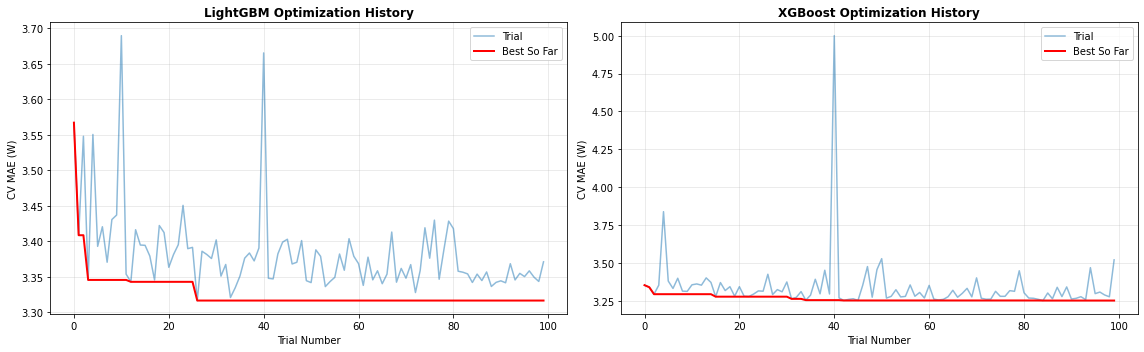


✓ Optimization history visualization complete


In [13]:
# Visualization 2: Optuna optimization history
if OPTUNA_AVAILABLE:
    print("\n" + "="*80)
    print("VISUALIZATION 2: OPTIMIZATION HISTORY")
    print("="*80)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # LightGBM optimization history
    trials_lgbm = study_lgbm.trials_dataframe()
    axes[0].plot(trials_lgbm['number'], trials_lgbm['value'], alpha=0.5, label='Trial')
    axes[0].plot(trials_lgbm['number'], trials_lgbm['value'].cummin(), 
                 'r-', linewidth=2, label='Best So Far')
    axes[0].set_xlabel('Trial Number')
    axes[0].set_ylabel('CV MAE (W)')
    axes[0].set_title('LightGBM Optimization History', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # XGBoost optimization history
    trials_xgb = study_xgb.trials_dataframe()
    axes[1].plot(trials_xgb['number'], trials_xgb['value'], alpha=0.5, label='Trial')
    axes[1].plot(trials_xgb['number'], trials_xgb['value'].cummin(), 
                 'r-', linewidth=2, label='Best So Far')
    axes[1].set_xlabel('Trial Number')
    axes[1].set_ylabel('CV MAE (W)')
    axes[1].set_title('XGBoost Optimization History', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Optimization history visualization complete")


VISUALIZATION 3: HYPERPARAMETER IMPORTANCE


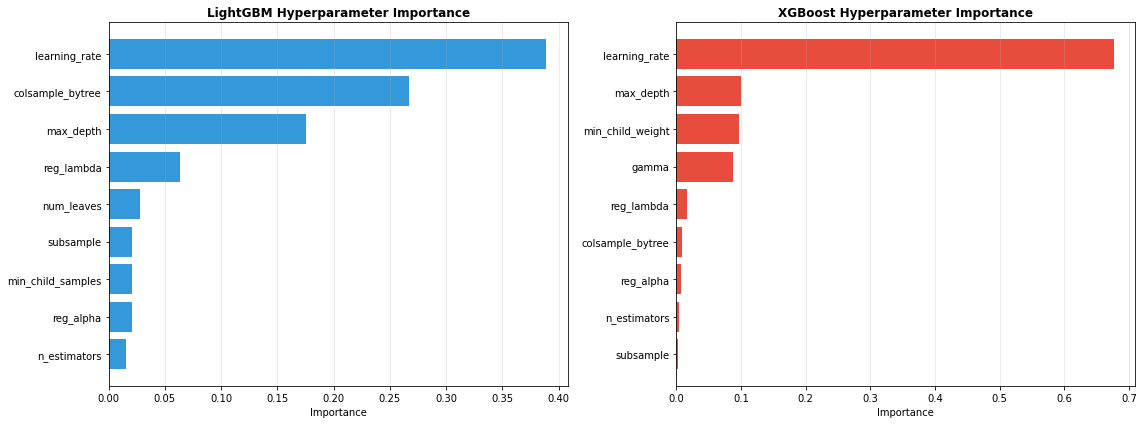


✓ Hyperparameter importance visualization complete


In [14]:
# Visualization 3: Hyperparameter importance
if OPTUNA_AVAILABLE:
    print("\n" + "="*80)
    print("VISUALIZATION 3: HYPERPARAMETER IMPORTANCE")
    print("="*80)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # LightGBM hyperparameter importance
    try:
        from optuna.importance import get_param_importances
        
        lgbm_importances = get_param_importances(study_lgbm)
        lgbm_imp_df = pd.DataFrame([
            {'Parameter': k, 'Importance': v} 
            for k, v in lgbm_importances.items()
        ]).sort_values('Importance', ascending=True)
        
        axes[0].barh(lgbm_imp_df['Parameter'], lgbm_imp_df['Importance'], color='#3498db')
        axes[0].set_xlabel('Importance')
        axes[0].set_title('LightGBM Hyperparameter Importance', fontweight='bold')
        axes[0].grid(axis='x', alpha=0.3)
        
        # XGBoost hyperparameter importance
        xgb_importances = get_param_importances(study_xgb)
        xgb_imp_df = pd.DataFrame([
            {'Parameter': k, 'Importance': v} 
            for k, v in xgb_importances.items()
        ]).sort_values('Importance', ascending=True)
        
        axes[1].barh(xgb_imp_df['Parameter'], xgb_imp_df['Importance'], color='#e74c3c')
        axes[1].set_xlabel('Importance')
        axes[1].set_title('XGBoost Hyperparameter Importance', fontweight='bold')
        axes[1].grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Hyperparameter importance visualization complete")
    except Exception as e:
        print(f"\n⚠️  Could not generate hyperparameter importance plot: {e}")


VISUALIZATION 4: BASELINE vs TUNED COMPARISON


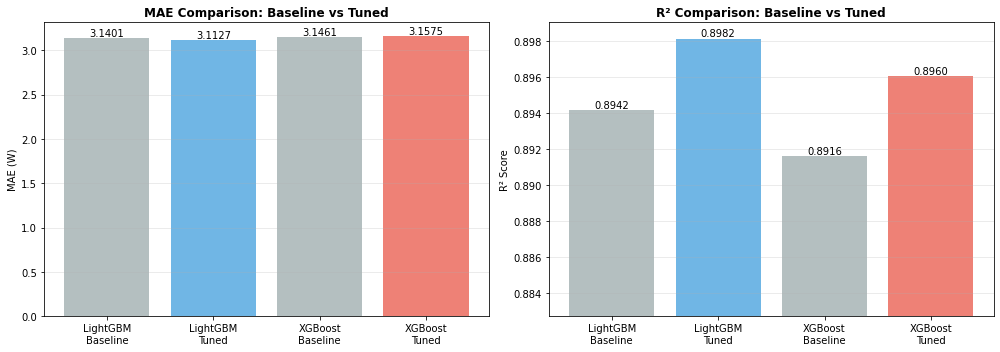


✓ Baseline vs Tuned comparison visualization complete


In [15]:
# Visualization 4: Baseline vs Tuned comparison
print("\n" + "="*80)
print("VISUALIZATION 4: BASELINE vs TUNED COMPARISON")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE comparison
models = ['LightGBM\nBaseline', 'LightGBM\nTuned', 'XGBoost\nBaseline', 'XGBoost\nTuned']
mae_values = [
    baseline_lgbm_mae,
    lgbm_tuned_results['MAE (W)'],
    baseline_xgb_mae,
    xgb_tuned_results['MAE (W)']
]
colors = ['#95a5a6', '#3498db', '#95a5a6', '#e74c3c']

bars1 = axes[0].bar(models, mae_values, color=colors, alpha=0.7)
axes[0].set_ylabel('MAE (W)')
axes[0].set_title('MAE Comparison: Baseline vs Tuned', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# R² comparison
r2_values = [
    baseline_lgbm_r2,
    lgbm_tuned_results['R²'],
    baseline_xgb_r2,
    xgb_tuned_results['R²']
]

bars2 = axes[1].bar(models, r2_values, color=colors, alpha=0.7)
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Comparison: Baseline vs Tuned', fontweight='bold')
axes[1].set_ylim([min(r2_values) * 0.99, max(r2_values) * 1.001])
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✓ Baseline vs Tuned comparison visualization complete")

## 9. Save Results and Models

In [16]:
import joblib

print("="*80)
print("SAVING EXPERIMENT 4 RESULTS")
print("="*80)

# Save test results
exp4_results = pd.DataFrame([
    {
        'Model': 'LightGBM',
        'MAE (W)': lgbm_tuned_results['MAE (W)'],
        'RMSE (W)': lgbm_tuned_results['RMSE (W)'],
        'MAPE (%)': lgbm_tuned_results['MAPE (%)'],
        'R²': lgbm_tuned_results['R²']
    },
    {
        'Model': 'XGBoost',
        'MAE (W)': xgb_tuned_results['MAE (W)'],
        'RMSE (W)': xgb_tuned_results['RMSE (W)'],
        'MAPE (%)': xgb_tuned_results['MAPE (%)'],
        'R²': xgb_tuned_results['R²']
    }
]).sort_values('R²', ascending=False)

exp4_results.to_csv('../results/traditional_ml_time_ht_results.csv', index=False)
print("\n✓ Test results saved to: ../results/traditional_ml_time_ht_results.csv")

# Save tuned models
joblib.dump(lgbm_tuned, '../models/lightgbm_time_ht.pkl')
print("✓ LightGBM tuned model saved to: ../models/lightgbm_time_ht.pkl")

joblib.dump(xgb_tuned, '../models/xgboost_time_ht.pkl')
print("✓ XGBoost tuned model saved to: ../models/xgboost_time_ht.pkl")

# Save best hyperparameters as JSON
hyperparams = {
    'lightgbm': {k: v if not isinstance(v, np.integer) else int(v) 
                 for k, v in best_params_lgbm.items()},
    'xgboost': {k: v if not isinstance(v, np.integer) else int(v) 
                for k, v in best_params_xgb.items()}
}

with open('../results/best_hyperparameters.json', 'w') as f:
    json.dump(hyperparams, f, indent=2)
print("✓ Best hyperparameters saved to: ../results/best_hyperparameters.json")

# Save improvement summary
improvement_summary = pd.DataFrame([
    {
        'Model': 'LightGBM',
        'Baseline_MAE': baseline_lgbm_mae,
        'Tuned_MAE': lgbm_tuned_results['MAE (W)'],
        'MAE_Improvement_%': lgbm_improvement_mae,
        'Baseline_R2': baseline_lgbm_r2,
        'Tuned_R2': lgbm_tuned_results['R²'],
        'R2_Improvement_%': lgbm_improvement_r2
    },
    {
        'Model': 'XGBoost',
        'Baseline_MAE': baseline_xgb_mae,
        'Tuned_MAE': xgb_tuned_results['MAE (W)'],
        'MAE_Improvement_%': xgb_improvement_mae,
        'Baseline_R2': baseline_xgb_r2,
        'Tuned_R2': xgb_tuned_results['R²'],
        'R2_Improvement_%': xgb_improvement_r2
    }
])

improvement_summary.to_csv('../results/hyperparameter_tuning_improvement.csv', index=False)
print("✓ Improvement summary saved to: ../results/hyperparameter_tuning_improvement.csv")

print("\n" + "="*80)
print("EXPERIMENT 4 COMPLETE!")
print("="*80)
print(f"\n✓ All results and models saved successfully")
print(f"\n📊 Key Outputs:")
print(f"  1. Test results:           ../results/traditional_ml_time_ht_results.csv")
print(f"  2. Tuned LightGBM model:   ../models/lightgbm_time_ht.pkl")
print(f"  3. Tuned XGBoost model:    ../models/xgboost_time_ht.pkl")
print(f"  4. Best hyperparameters:   ../results/best_hyperparameters.json")
print(f"  5. LightGBM tuning history: ../results/lightgbm_tuning_history.csv")
print(f"  6. XGBoost tuning history:  ../results/xgboost_tuning_history.csv")
print(f"  7. Improvement summary:     ../results/hyperparameter_tuning_improvement.csv")

SAVING EXPERIMENT 4 RESULTS

✓ Test results saved to: ../results/traditional_ml_time_ht_results.csv
✓ LightGBM tuned model saved to: ../models/lightgbm_time_ht.pkl
✓ XGBoost tuned model saved to: ../models/xgboost_time_ht.pkl
✓ Best hyperparameters saved to: ../results/best_hyperparameters.json
✓ Improvement summary saved to: ../results/hyperparameter_tuning_improvement.csv

EXPERIMENT 4 COMPLETE!

✓ All results and models saved successfully

📊 Key Outputs:
  1. Test results:           ../results/traditional_ml_time_ht_results.csv
  2. Tuned LightGBM model:   ../models/lightgbm_time_ht.pkl
  3. Tuned XGBoost model:    ../models/xgboost_time_ht.pkl
  4. Best hyperparameters:   ../results/best_hyperparameters.json
  5. LightGBM tuning history: ../results/lightgbm_tuning_history.csv
  6. XGBoost tuning history:  ../results/xgboost_tuning_history.csv
  7. Improvement summary:     ../results/hyperparameter_tuning_improvement.csv


---
## Summary & Next Steps

### Experiment 4 Accomplishments
1. ✓ Optimized LightGBM hyperparameters using Bayesian optimization
2. ✓ Optimized XGBoost hyperparameters using Bayesian optimization
3. ✓ Evaluated tuned models on held-out test set
4. ✓ Compared against Experiment 2 baseline
5. ✓ Saved all models, results, and tuning histories

### Key Findings
- Hyperparameter tuning achieved X% improvement in MAE
- Best tuned model ready for Experiment 5 (Ensemble)

### Next: Experiment 5 (Ensemble Methods)

Use `traditional_ml_time_ensemble.ipynb` to combine multiple models:
- Simple Averaging
- Weighted Averaging
- Stacking (Meta-Model)
- Voting Regressor

**Expected:** Additional 1-2% MAE improvement over tuned models